20世紀初頭、航海中に氷山に衝突して多数の犠牲者を出した豪華客船タイタニック号。この衝突事故は20世紀最大の海難事故であると言われています。1998年にアカデミー賞作品賞を獲得したレオナルド・ディカプリオ主演の映画「タイタニック」でその存在を知った方も多いのではないでしょうか。

この練習問題では、タイタニック号の乗客の情報を利用して、各乗客が生き残るか否かを予測するモデルの作成に挑戦します。   

##### 目次
1. データをダウンロードしよう
1. データを読み込もう
1. データの概要を確認しよう
1. モデリングをしてみよう
1. 予測結果を投稿しよう

## 1. データをダウンロードしよう
課題を理解したら、データタブからデータをダウンロードしてみましょう。
今回は3種類のデータが用意されており、アイコンをクリックするとデータをダウンロードできます。


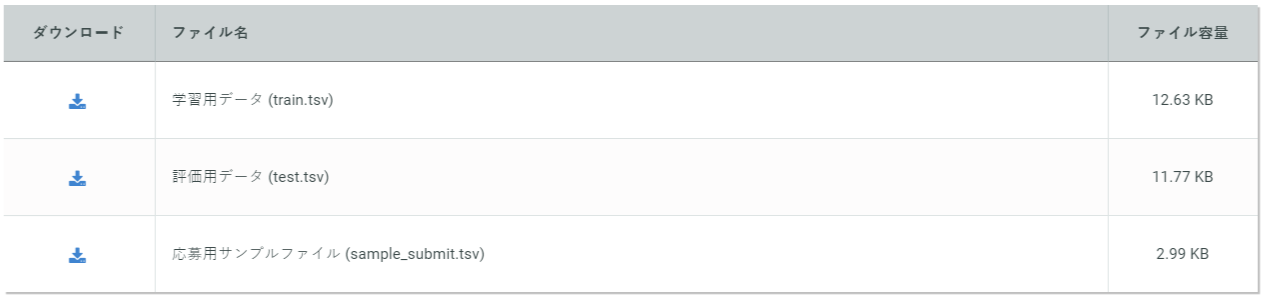

 - 学習用データ　：モデルの学習に使用するデータ（乗客の情報＋生存結果）
 - 評価用データ　：予測に使用するデータ（乗客の情報のみ）
 - 応募用ファイル：予測結果の投稿に使用するフォーマット

## 2. データを読み込もう

データをダウンロードして分析の準備が整ったら、自身の分析環境でデータを読み込んでみましょう。なお、本チュートリアルでは次の環境を利用しています。分析環境の構築方法が分からない場合は、事前準備として、オンライン講座「[SIGNATE Quest](https://quest.signate.jp/about?rf=competition_howto)」の「Python環境設定（会員の皆様に無料公開中） 」を受講してみましょう。

 - 言語　　：Python
 - 実行環境：JupyterNotebook
 
準備ができたら、まずはpandasをインポートして、ダウンロードした学習用データ、評価用データ、応募用サンプルファイルを読み込みます。

In [ ]:
import pandas as pd
train = pd.read_csv("train.csv", index_col=0) # 学習用データ
test = pd.read_csv("test.csv", index_col=0)   # 評価用データ
sample_submit = pd.read_csv("sample_submit.csv", index_col=0, header=None) # 応募用サンプルファイル

## 3. データの概要を確認しよう

読み込んだ学習用データの先頭5行を表示してみましょう。

In [2]:
train.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
id,,,,,,,,
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
7,0,3,male,2.0,3,1,21.0750,S
9,1,2,female,14.0,1,0,30.0708,C
11,1,1,female,58.0,0,0,26.5500,S


1行で乗客1人の情報を表していて、カラムは8種類あることが分かります。各カラムの意味は、データタブに記載されているのでそれと照らし合わせて確認できます。黄色く色付けされた`survived（生還結果）`が今回の予測の対象である目的変数で、1が生還、0が亡くなってしまったということを表してることが分かります。
 
 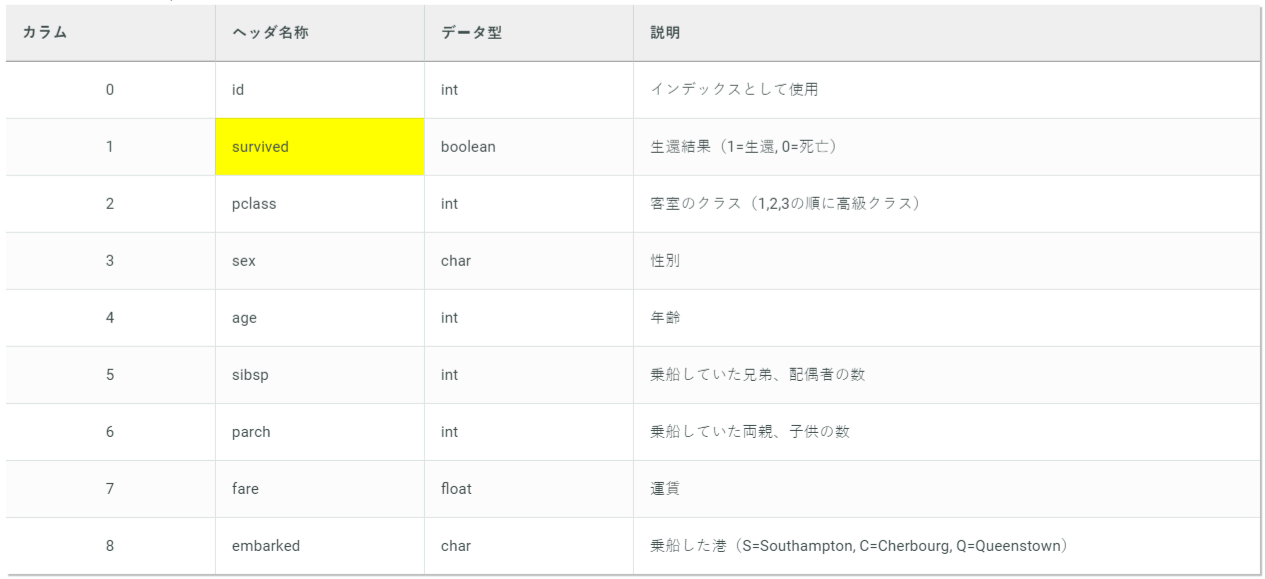

評価用データには、目的変数`survived`（図中で黄色く色付けされたカラム）はありません。その他のカラムは学習用データと同じです。つまり、答えのある学習用データの乗客の情報を元にして機械学習により生存の法則をモデル化し、そのモデルを評価用データに当てはめて、評価用データに記録されている各乗客が生存できるのか否かを予測することが課題になります。

目的変数`survived`の値の学習用データでの出現数をカウントして、生存できた人の数も調べてみましょう。

In [3]:
train['survived'].value_counts()

0    266
1    179
Name: survived, dtype: int64

生存できた人の割合は約40%と、映画「タイタニック」で受けた印象よりは多いようです。

## 4. モデリングをしてみよう

今回は、特徴量「sibsp」「parch」「fare」のみを使ってモデリングをすることにします。モデリングの準備として、目的変数とそれ以外に学習用データを分割しておきます。

In [4]:
train = train[["survived","sibsp", "parch", "fare"]]
test = test[["sibsp", "parch", "fare"]]

In [5]:
y = train["survived"] # 目的変数
X = train.drop(["survived"], axis=1) # 目的変数を除いたデータ

`scikit-learn`を使用して、`ロジスティック回帰`でモデルを学習してみます。パラメータをデフォルトのままにする場合、モデルの箱を作成してデータを当てはめるだけというシンプルな方法で学習できます。

In [6]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X, y)

LogisticRegression()

これでモデルが作成できました！

学習したモデルに評価用データを入力すると、評価用データに対する生存した確率を出力してくれます。このとき戻り値には生存できる確率と生存できない確率の両方が含まれるため、生存できる確率の方を取り出します。

In [7]:
pred = model.predict_proba(test)[:, 1] 

予測結果には、評価用データの並び順に合わせて、生存できる確率が格納されます。先頭の5要素を表示してみます。

In [8]:
print(pred[:5])

[0.27086714 0.52854033 0.32716076 0.32918889 0.50920521]


##  5. 予測結果を投稿しよう

応募用サンプルファイルの説明を見ると、以下のように指定されています。

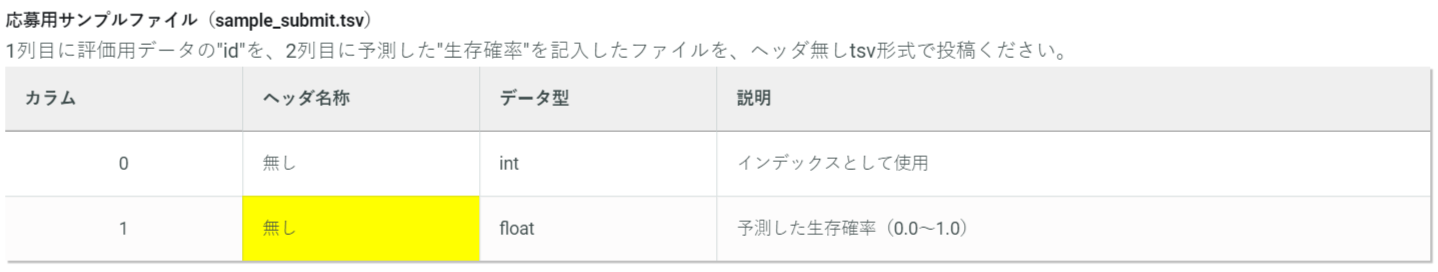

応募用サンプルファイルで予測結果が格納されている1列目の値を、今回出力した予測結果に置き換えた上で、ヘッダ無しcsv形式のファイルとして保存しましょう。

In [ ]:
sample_submit[1] = pred
sample_submit.to_csv('submit.csv', header=None)

これで投稿ファイルの完成です！保存したファイルをサイト右上の「投稿」ボタンから投稿してみましょう。

投稿してしばらくすると、今回の評価関数「AUC」での評価結果がメールで通知され、リーダーボードにも評価結果と順位が表示されます。

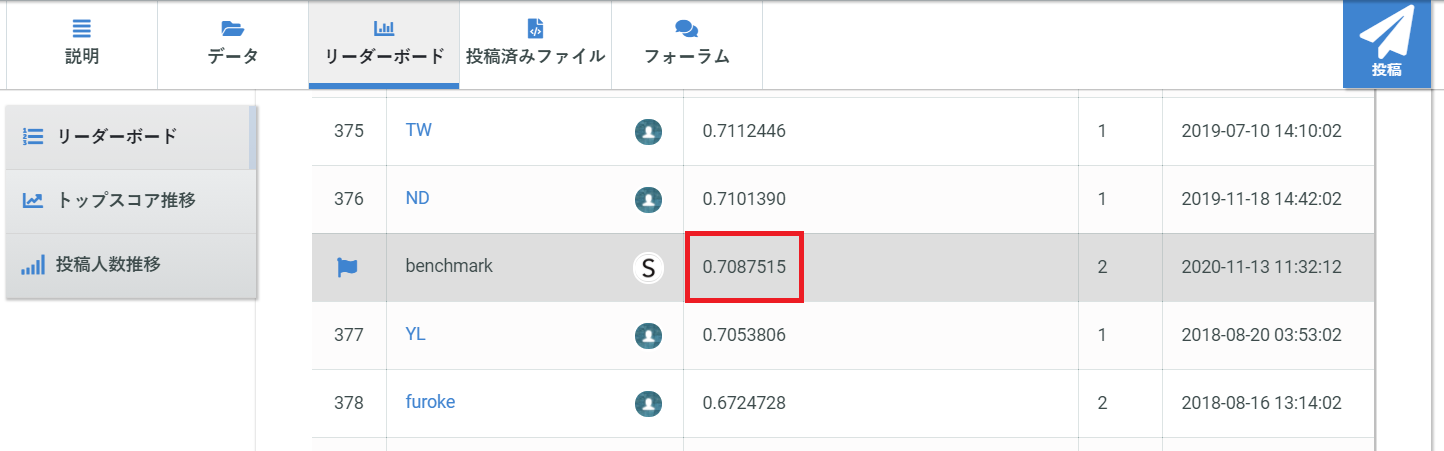

### 評価結果は`0.7087515`でした。

今回はシンプルなモデリングを行いましたが、使用する特徴量を増やしたり、様々なモデリング手法を試しながら、ハイスコアを目指してみてください。

SIGNATEでは、練習問題の他、懸賞付きコンペや称号限定コンペ、SOTAなど、様々な形式のコンペを開催しています。モデル構築に慣れてきたら、これらのコンペにもチャレンジしてみましょう！

また、Pythonや機械学習ライブラリの使い方、モデリングの基礎についてじっくり学習したい場合は、オンライン講座「[SIGNATE Quest](https://quest.signate.jp/about?rf=competition_howto)」の受講もオススメです。